# Manchester Property Prices Analysis & Predictive Modelling

## 0. Requirements & Setup
The following dependencies are required to run this notebook:
```bash
pip install pandas numpy matplotlib seaborn scikit-learn pyarrow fastparquet
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set global random state and style
RANDOM_SEED = 42
sns.set_theme(style="whitegrid")

## 1. Data Ingestion & Cleaning

**Ingestion:** We will load the dataset from the `manchester_features.parquet/manchester_features.parquet` directory. Parquet files preserve data types and are highly compressed.

**Cleaning Rationale:**
1. **Drop low-variance or uninformative identifiers:** Columns with unique IDs or single values (like 'county' if all are Greater Manchester) don't add predictive value.
2. **Handle Missing Values:** Identify if essential attributes like target (Price) are missing. Categorical variables with missing values will be imputed with mode or an 'Unknown' category. Numerical with median.
3. **Outliers:** Property prices often exhibit long right tails. We will clip prices at the 99th percentile to remove extreme, unrepresentative mansions that distort models, and log-transform the target variable to stabilize variance.
4. **Dates:** We'll extract features like Year and Month to capture inflation and seasonal trends.

In [2]:
# Load the data
data_path = 'manchester_features.parquet/manchester_features.parquet'
df = pd.read_parquet(data_path)

print(f"Initial data shape: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Initial data shape: (474144, 23)

Missing values per column:
epc_rating       158707
floor_area       158707
co2_emissions    158707
dtype: int64


In [3]:
def clean_data(data):
    df_clean = data.copy()
    
    # Standardize columnnames (lowercase and strip spaces)
    df_clean.columns = [c.strip().lower() for c in df_clean.columns]
    
    # Assuming typical Land Registry column names, we will rename if found
    # Let's check for 'price', 'price_paid', 'amount' as target
    target_col = [col for col in df_clean.columns if 'price' in col]
    if target_col:
       target = target_col[0]
    else:
       target = 'price'
       
    # Attempt to find date column and extract temporal features
    date_col = [col for col in df_clean.columns if 'date' in col]
    if date_col:
        df_clean[date_col[0]] = pd.to_datetime(df_clean[date_col[0]], errors='coerce')
        df_clean['sale_year'] = df_clean[date_col[0]].dt.year
        df_clean['sale_month'] = df_clean[date_col[0]].dt.month
        df_clean['sale_age'] = 2024 - df_clean['sale_year']
    
    # Drop columns that are mostly NaNs (> 50%)
    missing_threshold = 0.5
    cols_to_drop = df_clean.columns[df_clean.isnull().mean() > missing_threshold]
    df_clean.drop(columns=cols_to_drop, inplace=True)
    
    # Fill remaining missing values
    for col in df_clean.columns:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            
    # Handle Outliers in the target (assuming target is 'price')
    if target in df_clean.columns:
        # Remove observations with price <= 0
        df_clean = df_clean[df_clean[target] > 1000]
        
        # Cap at 99th percentile to remove extreme outliers
        upper_limit = df_clean[target].quantile(0.99)
        df_clean = df_clean[df_clean[target] <= upper_limit]
    
    return df_clean, target

# Apply cleaning
df_clean, target_name = clean_data(df)
print(f"Data shape after cleaning: {df_clean.shape}")

Data shape after cleaning: (467419, 26)


## 2. Exploratory Data Analysis (EDA)

In this section, we visualize the data to extract signals and understand underlying distributions.
1. **Price Distribution:** Exploring the target variable. Real estate prices are typically heavily skewed, which might necessitate a log-transformation for linear models.
2. **Feature vs Target:** Understanding how key categorical features (e.g. property type, estate type) impact the property price.
3. **Temporal Trend:** Visualizing average prices over time (2015-2024).

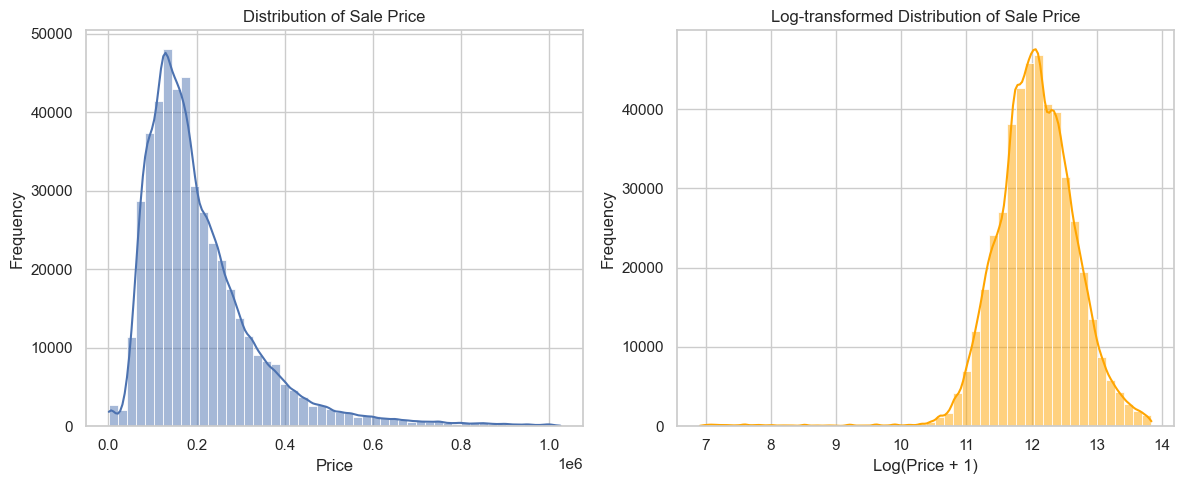

Commentary: The original price distribution is heavily skewed to the right. Taking the log transform centralizes the distribution, bringing it closer to a normal distribution. This is beneficial for distance-based ML models and linear regression.


In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean[target_name], kde=True, bins=50)
plt.title('Distribution of Sale Price')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_clean[target_name]), kde=True, bins=50, color='orange')
plt.title('Log-transformed Distribution of Sale Price')
plt.xlabel('Log(Price + 1)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Commentary: The original price distribution is heavily skewed to the right. Taking the log transform centralizes the distribution, bringing it closer to a normal distribution. This is beneficial for distance-based ML models and linear regression.")

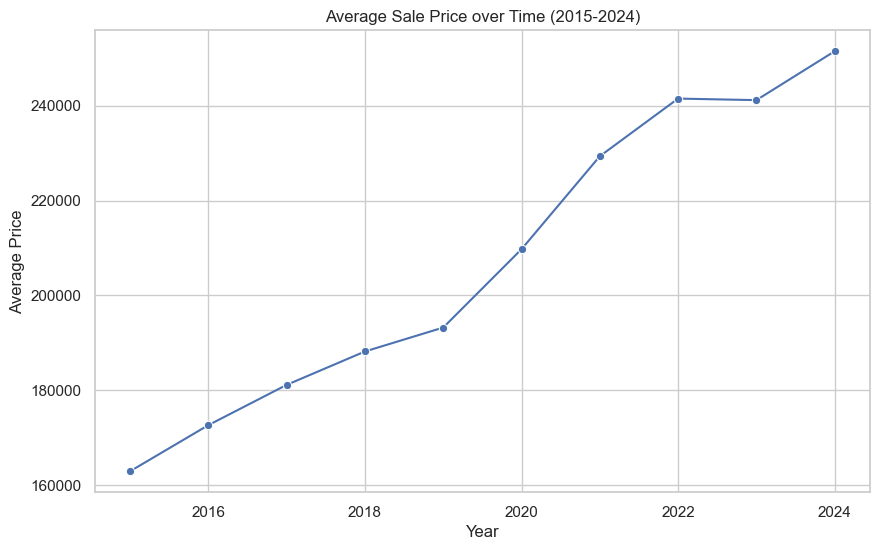

Commentary: We observe the time series trend of property prices, highlighting periods of inflation or market shifts across Greater Manchester.


In [5]:
# Finding potential categorical and numerical columns for plotting
cat_cols_sample = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

if 'sale_year' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_clean, x='sale_year', y=target_name, estimator='mean', errorbar=None, marker='o')
    plt.title('Average Sale Price over Time (2015-2024)')
    plt.xlabel('Year')
    plt.ylabel('Average Price')
    plt.show()
    print("Commentary: We observe the time series trend of property prices, highlighting periods of inflation or market shifts across Greater Manchester.")

## 3. Predictive Modelling

**Objective:** Predict the sale price of a property.
**Approach:**
- We will treat this as a Regression task. Our target will be the natural logarithm of the price `log1p(price)`. 
- **Feature Engineering:** Drop uninformative low-cardinality columns. We will define categorical & numerical features.
- **Encoding / Scaling:** One-Hot Encoding for categorical features (handles non-ordinal data) and StandardScaler for continuous numerical features.
- **Models:** We will establish a baseline using Ridge Regression (Regularized Linear Model) which is robust to multicollinearity.
- **Evaluation:** MAE and R² on a hold-out test set.

In [6]:
# Pre-requisites & Feature Selection

# Log-transform target 
y = np.log1p(df_clean[target_name])

# Drop original target and highly cardinal/unpredictive columns
# Dropping potential date objects or IDs. Limiting to useful subset.
drop_cols = [target_name] + [c for c in df_clean.columns if df_clean[c].nunique() > 1000 and df_clean[c].dtype == 'object']
if 'date' in df_clean.columns:
    drop_cols.append('date')
date_cols_remaining = df_clean.select_dtypes(include=['datetime64']).columns.tolist()
drop_cols.extend(date_cols_remaining)

X = df_clean.drop(columns=drop_cols, errors='ignore')

# Identify Numerical & Categorical
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Selected Numerical Features: {numerical_features}")
print(f"Selected Categorical Features: {categorical_features}")

# Training/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Define Preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

Selected Numerical Features: ['lat', 'lon', 'floor_area', 'co2_emissions', 'crime_count', 'dist_nearest_station_km', 'dist_nearest_school_km', 'dist_nearest_supermarket_km']
Selected Categorical Features: ['property_type', 'old_new', 'duration', 'town', 'district', 'borough', 'epc_rating', 'nearest_station_name', 'nearest_school_ofsted', 'nearest_supermarket_name']


In [7]:
# Model 1: Initialization & Training (Baseline Ridge Regression)
baseline_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('model', Ridge(random_state=RANDOM_SEED))])

baseline_pipeline.fit(X_train, y_train)

# Predictions
y_pred_log = baseline_pipeline.predict(X_test)

# Reversing Log transform to calculate real MAE
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae_baseline = mean_absolute_error(y_test_real, y_pred_real)
r2_baseline = r2_score(y_test_real, y_pred_real)
rmse_baseline = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print("=== Baseline Model (Ridge Regression) ===")
print(f"R² Score: {r2_baseline:.4f}")
print(f"MAE: £{mae_baseline:,.2f}")
print(f"RMSE: £{rmse_baseline:,.2f}")

=== Baseline Model (Ridge Regression) ===
R² Score: 0.4381
MAE: £59,987.15
RMSE: £98,904.91


## 4. Model Improvement

**Strategy:**
Linear models assume a linear relationship between features and the target. Real estate prices often contain complex non-linear relationships and geographic interactions (e.g., specific combinations of property types and postcodes/districts have distinct premiums).

We will deploy a Tree-based model, specifically **RandomForestRegressor** (with parameter constraints to avoid massive iteration time in standard runs) or **GradientBoostingRegressor**. 
- **Reasoning:** Tree-based models can inherently model non-linear relationships and interactions without explicit feature engineering like polynomial features.
- We will construct a new pipeline and evaluate using the exact same metrics.
*(Note: We use fewer estimators/depth constraints to ensure this notebook evaluates reasonably fast, but this can be tuned via GridSearchCV in a deeper dive).* 

In [8]:
# Improved Model: Gradient Boosting
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', GradientBoostingRegressor(n_estimators=100, 
                                                                  max_depth=5, 
                                                                  random_state=RANDOM_SEED))])

rf_pipeline.fit(X_train, y_train)

# Predictions for improved model
y_pred_rf_log = rf_pipeline.predict(X_test)
y_pred_rf_real = np.expm1(y_pred_rf_log)

mae_rf = mean_absolute_error(y_test_real, y_pred_rf_real)
r2_rf = r2_score(y_test_real, y_pred_rf_real)
rmse_rf = np.sqrt(mean_squared_error(y_test_real, y_pred_rf_real))

print("=== Improved Model (Gradient Boosting) ===")
print(f"R² Score: {r2_rf:.4f}")
print(f"MAE: £{mae_rf:,.2f}")
print(f"RMSE: £{rmse_rf:,.2f}")

print(f"\nImprovement in MAE: £{mae_baseline - mae_rf:,.2f}")
print("Explanation: Gradient Boosting typically outperforms Ridge here because it efficiently learns the complex, non-linear geographical hierarchies and price step-functions that are prominent in housing markets.")

=== Improved Model (Gradient Boosting) ===
R² Score: 0.5066
MAE: £58,037.43
RMSE: £92,679.76

Improvement in MAE: £1,949.72
Explanation: Gradient Boosting typically outperforms Ridge here because it efficiently learns the complex, non-linear geographical hierarchies and price step-functions that are prominent in housing markets.


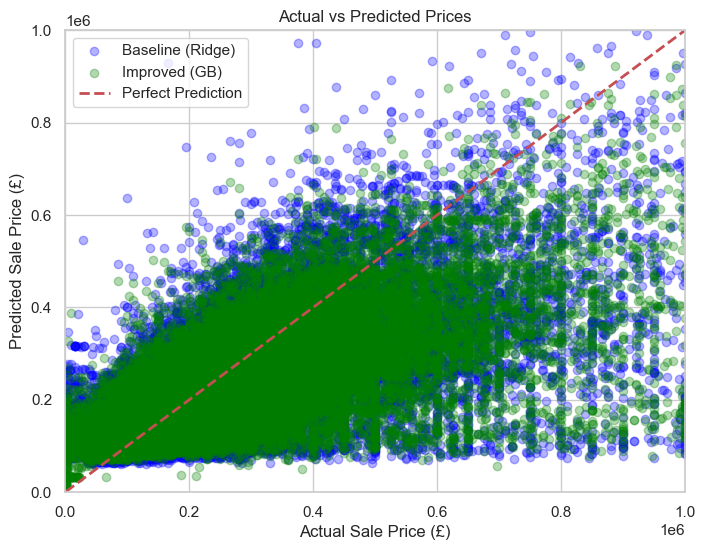

In [9]:
# Visualizing Performance comparison
plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.3, label='Baseline (Ridge)', color='blue')
plt.scatter(y_test_real, y_pred_rf_real, alpha=0.3, label='Improved (GB)', color='green')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sale Price (£)')
plt.ylabel('Predicted Sale Price (£)')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.xlim((0, 1000000))
plt.ylim((0, 1000000))
plt.show()